
# 数据分析与可视化模拟考试报告：电影数据分析



## 1. 环境准备与数据读取

本节先导入常用库，并尝试使用多种编码读取 CSV 文件，避免考试中因编码问题导致读取失败。


In [1]:

# 基础库导入
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

# 让表格显示更完整
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# 设置中文字体，避免图中中文乱码
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
font_candidates = ["Microsoft YaHei", "SimHei", "Noto Sans CJK JP", "Arial Unicode MS", "AR PL UMing CN", "DejaVu Sans"]
for font in font_candidates:
    if font in available_fonts:
        plt.rcParams["font.sans-serif"] = [font]
        break

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# 读取数据：优先读取当前目录下的文件，若不存在则读取 /mnt/data 中的文件
possible_paths = [Path("实例数据.csv"), Path("/mnt/data/实例数据.csv")]
data_path = None
for p in possible_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("没有找到 实例数据.csv，请确认 CSV 文件与 Notebook 放在同一文件夹。")

# 尝试多种常见编码
encodings = ["utf-8", "utf-8-sig", "gbk", "gb18030"]
last_error = None
for enc in encodings:
    try:
        raw = pd.read_csv(data_path, encoding=enc)
        used_encoding = enc
        break
    except Exception as e:
        last_error = e
else:
    raise last_error

print(f"数据文件路径：{data_path}")
print(f"成功读取编码：{used_encoding}")
print(f"数据规模：{raw.shape[0]} 行，{raw.shape[1]} 列")

display(raw.head())


数据文件路径：实例数据.csv
成功读取编码：utf-8
数据规模：1000 行，12 列


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.10,757074,333.13,76.00
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.00,485820,126.46,65.00
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.30,157606,138.12,62.00
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.20,60545,270.32,59.00
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.20,393727,325.02,40.00



## 2. 数据基本信息与字段含义

先查看字段名称、数据类型、样例数据和基本维度，明确每一列能支持哪些分析问题。


In [2]:

# 查看字段名称、数据类型和非空数量
display(pd.DataFrame({
    "字段名": raw.columns,
    "数据类型": raw.dtypes.astype(str).values,
    "非空数量": raw.notna().sum().values,
    "缺失数量": raw.isna().sum().values,
    "缺失率": (raw.isna().mean().values * 100).round(2).astype(str) + "%"
}))

# 字段含义说明
field_meaning = pd.DataFrame({
    "字段": ["Rank", "Title", "Genre", "Description", "Director", "Actors", "Year",
           "Runtime (Minutes)", "Rating", "Votes", "Revenue (Millions)", "Metascore"],
    "含义": ["电影排名", "电影标题", "电影类型，可能包含多个类型", "电影简介", "导演", "主要演员",
           "上映年份", "电影时长，单位为分钟", "用户评分", "投票人数", "票房收入，单位为百万美元", "媒体评分"],
    "可用于的分析": ["排序参考", "识别电影", "类型结构与分组比较", "文本说明，通常不直接统计", "导演维度分析",
                  "演员维度分析", "年份趋势分析", "时长分布与评分关系", "口碑评价分析",
                  "受关注程度分析", "商业表现分析", "专业评价分析"]
})

display(field_meaning)


,字段名,数据类型,非空数量,缺失数量,缺失率
0,Rank,int64,1000,0,0.0%
1,Title,str,1000,0,0.0%
2,Genre,str,1000,0,0.0%
3,Description,str,1000,0,0.0%
4,Director,str,1000,0,0.0%
5,Actors,str,1000,0,0.0%
6,Year,int64,1000,0,0.0%
7,Runtime (Minutes),int64,1000,0,0.0%
8,Rating,float64,1000,0,0.0%
9,Votes,int64,1000,0,0.0%


,字段,含义,可用于的分析
0,Rank,电影排名,排序参考
1,Title,电影标题,识别电影
2,Genre,电影类型，可能包含多个类型,类型结构与分组比较
3,Description,电影简介,文本说明，通常不直接统计
4,Director,导演,导演维度分析
5,Actors,主要演员,演员维度分析
6,Year,上映年份,年份趋势分析
7,Runtime (Minutes),电影时长，单位为分钟,时长分布与评分关系
8,Rating,用户评分,口碑评价分析
9,Votes,投票人数,受关注程度分析



## 3. 分析目标设计

结合数据字段，本次分析重点回答以下问题：

1. 数据质量是否可靠？是否存在缺失值、重复值、异常值或类型问题？  
2. 电影类型结构有什么特点？哪些类型出现频率最高？  
3. 电影评分、票房、投票数、时长的总体分布如何？  
4. 不同电影类型在评分和票房表现上是否存在差异？  
5. 年份、评分、票数、媒体评分和票房之间是否存在可解释的关系？



## 4. 数据质量检查

本节检查缺失值、重复值和异常值。考试中不要一上来就删除数据，应先说明问题，再决定处理方式。


In [3]:

# 4.1 缺失值检查
missing_table = pd.DataFrame({
    "缺失数量": raw.isna().sum(),
    "缺失率": (raw.isna().mean() * 100).round(2).astype(str) + "%"
}).sort_values("缺失数量", ascending=False)

print("各字段缺失情况：")
display(missing_table)

# 4.2 重复值检查
full_duplicate_count = raw.duplicated().sum()
title_duplicate_count = raw.duplicated(subset=["Title"]).sum()

print(f"完全重复行数量：{full_duplicate_count}")
print(f"电影标题重复数量：{title_duplicate_count}")

if title_duplicate_count > 0:
    print("标题重复的记录如下：")
    display(raw[raw.duplicated(subset=["Title"], keep=False)][["Rank", "Title", "Year", "Director", "Rating", "Revenue (Millions)"]])

# 4.3 数值字段范围检查
numeric_cols = ["Rank", "Year", "Runtime (Minutes)", "Rating", "Votes", "Revenue (Millions)", "Metascore"]
display(raw[numeric_cols].describe().T)


各字段缺失情况：


,缺失数量,缺失率
Revenue (Millions),128,12.8%
Metascore,64,6.4%
Rank,0,0.0%
Title,0,0.0%
Description,0,0.0%
Genre,0,0.0%
Director,0,0.0%
Actors,0,0.0%
Runtime (Minutes),0,0.0%
Year,0,0.0%


完全重复行数量：0
电影标题重复数量：1
标题重复的记录如下：


,Rank,Title,Year,Director,Rating,Revenue (Millions)
239,240,The Host,2013,Andrew Niccol,5.90,26.62
632,633,The Host,2006,Bong Joon Ho,7.00,2.20


,count,mean,std,min,25%,50%,75%,max
Rank,"1,000.00",500.50,288.82,1.00,250.75,500.50,750.25,"1,000.00"
Year,"1,000.00","2,012.78",3.21,"2,006.00","2,010.00","2,014.00","2,016.00","2,016.00"
Runtime (Minutes),"1,000.00",113.17,18.81,66.00,100.00,111.00,123.00,191.00
Rating,"1,000.00",6.72,0.95,1.90,6.20,6.80,7.40,9.00
Votes,"1,000.00","169,808.26","188,762.65",61.00,"36,309.00","110,799.00","239,909.75","1,791,916.00"
Revenue (Millions),872.00,82.96,103.25,0.00,13.27,47.98,113.72,936.63
Metascore,936.00,58.99,17.19,11.00,47.00,59.50,72.00,100.00


In [4]:

# 4.4 使用 IQR 方法检查数值型异常值
outlier_rows = []
for col in ["Runtime (Minutes)", "Rating", "Votes", "Revenue (Millions)", "Metascore"]:
    s = raw[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((s < lower) | (s > upper)).sum()
    outlier_rows.append([col, q1, q3, lower, upper, outlier_count])

outlier_table = pd.DataFrame(outlier_rows, columns=["字段", "Q1", "Q3", "下界", "上界", "IQR异常值数量"])
display(outlier_table)


,字段,Q1,Q3,下界,上界,IQR异常值数量
0,Runtime (Minutes),100.00,123.00,65.50,157.50,30
1,Rating,6.20,7.40,4.40,9.20,19
2,Votes,"36,309.00","239,909.75","-269,092.12","545,310.88",45
3,Revenue (Millions),13.27,113.72,-137.40,264.38,55
4,Metascore,47.00,72.00,9.50,109.50,0


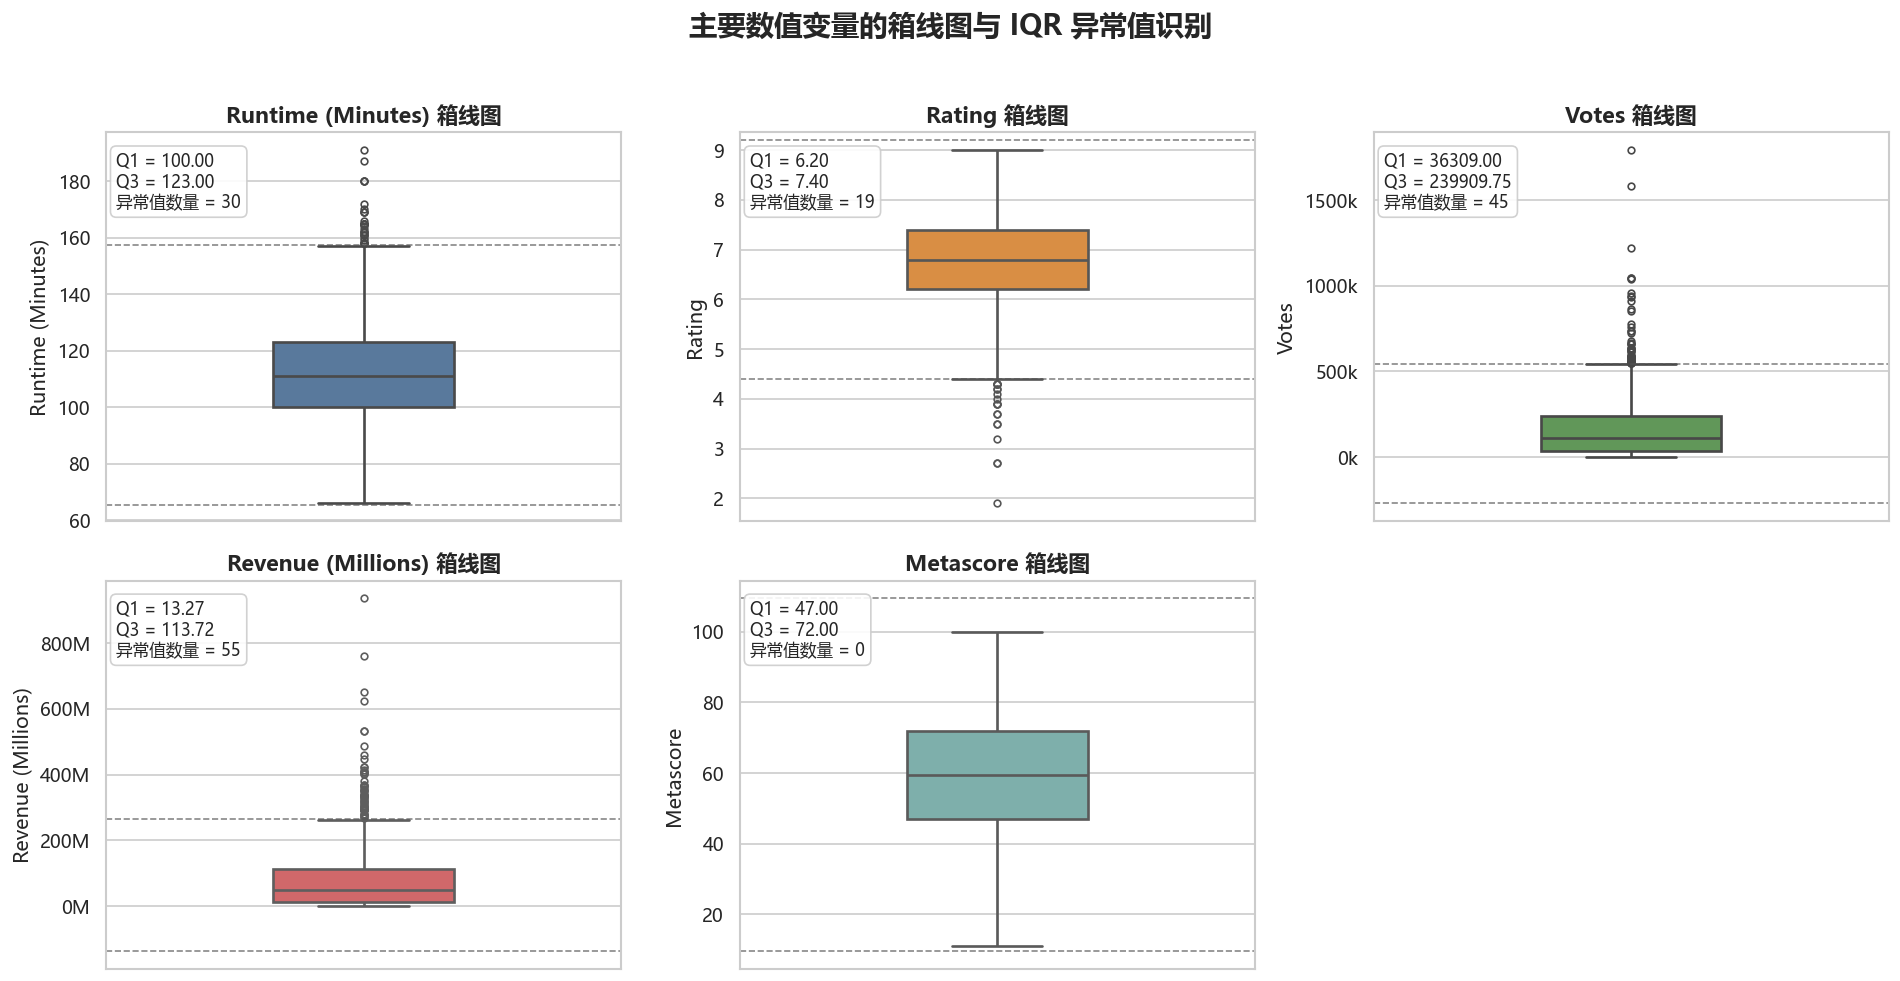

In [19]:
# 4.5 使用箱线图直观展示数值型异常值分布

import seaborn as sns
from matplotlib.ticker import FuncFormatter

# 需要检查异常值的数值型字段
box_cols = ["Runtime (Minutes)", "Rating", "Votes", "Revenue (Millions)", "Metascore"]

# 统一设置图表风格，让图更高级、美观
sns.set_theme(style="whitegrid", font=plt.rcParams["font.sans-serif"][0])
palette = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#76B7B2"]

# 创建子图
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    ax = axes[i]
    
    # 去除缺失值
    data = raw[col].dropna()
    
    # 计算 IQR 相关指标
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((data < lower) | (data > upper)).sum()
    
    # 绘制箱线图
    sns.boxplot(
        y=data,
        ax=ax,
        color=palette[i],
        width=0.35,
        linewidth=1.6,
        fliersize=4
    )
    
    # 添加上下界参考线
    ax.axhline(lower, color="#555555", linestyle="--", linewidth=1, alpha=0.7)
    ax.axhline(upper, color="#555555", linestyle="--", linewidth=1, alpha=0.7)
    
    # 图表标题和标签
    ax.set_title(f"{col} 箱线图", fontsize=13, fontweight="bold")
    ax.set_ylabel(col)
    ax.set_xlabel("")
    
    # 添加文字说明
    ax.text(
        0.02, 0.95,
        f"Q1 = {q1:.2f}\nQ3 = {q3:.2f}\n异常值数量 = {outlier_count}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="#CCCCCC",
            alpha=0.9
        )
    )
    
    # 对票数这类大数值字段做格式美化
    if col == "Votes":
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
    elif col == "Revenue (Millions)":
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}M"))

# 删除多余的第 6 个空白子图
fig.delaxes(axes[-1])

fig.suptitle("主要数值变量的箱线图与 IQR 异常值识别", fontsize=17, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**箱线图解读：**  
从箱线图可以看出，`Runtime (Minutes)`、`Rating`、`Votes` 和 `Revenue (Millions)` 均存在一定数量的 IQR 异常值，其中 `Votes` 和 `Revenue (Millions)` 的异常值数量较多。这类异常值主要表现为远高于普通电影的投票数或票房收入，通常对应热门电影或商业大片，并不一定是数据录入错误。因此，后续分析中不直接删除这些异常值，而是在票房分析中采用中位数、对数坐标或分组统计等方式降低极端值对结论的影响。`Metascore` 未发现明显 IQR 异常值，说明媒体评分整体分布相对稳定。


**数据质量小结：**

- 数据共有 1000 条电影记录、12 个字段，整体结构清晰。
- 缺失值主要集中在 `Revenue (Millions)` 和 `Metascore` 两列，说明部分电影缺少票房或媒体评分信息。
- 完全重复行数量为 0，说明没有直接重复记录。
- `Title` 存在少量重复，但结合年份和导演可以看出并不是同一部电影的重复录入，因此不应直接删除。
- 票房、投票数等字段存在较高值，这类异常值往往代表热门大片或高关注电影，不是错误数据，应保留；后续在相关图表中使用对数坐标或中位数等更稳健的统计方式。



## 5. 数据清洗与变量构造

清洗原则：

1. 去除文本字段首尾空格，统一字段命名格式。  
2. 对数值字段进行类型确认，保证可以参与统计计算。  
3. 缺失票房和媒体评分不简单填 0，因为缺失不等于没有收入或没有评分。  
4. 构造电影主类型、类型数量、评分等级、时长分组等变量，为后续分组分析做准备。


In [5]:

# 复制原始数据，避免直接修改 raw
df = raw.copy()

# 字段名规范化：便于 Python 代码调用
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

# 文本字段清洗：去除首尾空格
text_cols = ["title", "genre", "description", "director", "actors"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# 数值字段类型转换：若遇到异常字符，则转为缺失值
num_cols = ["rank", "year", "runtime_minutes", "rating", "votes", "revenue_millions", "metascore"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 构造变量
df["genre_list"] = df["genre"].str.split(",")
df["main_genre"] = df["genre_list"].str[0].str.strip()
df["genre_count"] = df["genre_list"].str.len()
df["lead_actor"] = df["actors"].str.split(",").str[0].str.strip()

df["rating_level"] = pd.cut(
    df["rating"],
    bins=[0, 6.0, 7.0, 8.0, 10],
    labels=["低于6分", "6-7分", "7-8分", "8分及以上"],
    right=False
)

df["runtime_group"] = pd.cut(
    df["runtime_minutes"],
    bins=[0, 90, 110, 130, 1000],
    labels=["90分钟以下", "90-110分钟", "110-130分钟", "130分钟以上"],
    right=False
)

df["revenue_missing"] = df["revenue_millions"].isna()
df["metascore_missing"] = df["metascore"].isna()

print("清洗后数据规模：", df.shape)
display(df.head())

# 保存清洗后的数据，便于检查和复用
cleaned_path = Path("实例数据_清洗后.csv")
df.to_csv(cleaned_path, index=False, encoding="utf-8-sig")
print(f"清洗后数据已保存为：{cleaned_path}")


清洗后数据规模： (1000, 20)


,rank,title,genre,description,director,actors,year,runtime_minutes,rating,votes,revenue_millions,metascore,genre_list,main_genre,genre_count,lead_actor,rating_level,runtime_group,revenue_missing,metascore_missing
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.10,757074,333.13,76.00,"[Action, Adventure, Sci-Fi]",Action,3,Chris Pratt,8分及以上,110-130分钟,False,False
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.00,485820,126.46,65.00,"[Adventure, Mystery, Sci-Fi]",Adventure,3,Noomi Rapace,7-8分,110-130分钟,False,False
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.30,157606,138.12,62.00,"[Horror, Thriller]",Horror,2,James McAvoy,7-8分,110-130分钟,False,False
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.20,60545,270.32,59.00,"[Animation, Comedy, Family]",Animation,3,Matthew McConaughey,7-8分,90-110分钟,False,False
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.20,393727,325.02,40.00,"[Action, Adventure, Fantasy]",Action,3,Will Smith,6-7分,110-130分钟,False,False


清洗后数据已保存为：实例数据_清洗后.csv



## 6. 描述性统计分析

本节从数值变量和类别变量两个角度了解数据的整体特征。


In [6]:

# 数值变量描述统计
summary_numeric = df[["year", "runtime_minutes", "rating", "votes", "revenue_millions", "metascore"]].describe().T
summary_numeric["missing"] = df[["year", "runtime_minutes", "rating", "votes", "revenue_millions", "metascore"]].isna().sum()
summary_numeric["missing_rate"] = (df[["year", "runtime_minutes", "rating", "votes", "revenue_millions", "metascore"]].isna().mean() * 100).round(2).astype(str) + "%"
display(summary_numeric)


,count,mean,std,min,25%,50%,75%,max,missing,missing_rate
year,"1,000.00","2,012.78",3.21,"2,006.00","2,010.00","2,014.00","2,016.00","2,016.00",0,0.0%
runtime_minutes,"1,000.00",113.17,18.81,66.00,100.00,111.00,123.00,191.00,0,0.0%
rating,"1,000.00",6.72,0.95,1.90,6.20,6.80,7.40,9.00,0,0.0%
votes,"1,000.00","169,808.26","188,762.65",61.00,"36,309.00","110,799.00","239,909.75","1,791,916.00",0,0.0%
revenue_millions,872.00,82.96,103.25,0.00,13.27,47.98,113.72,936.63,128,12.8%
metascore,936.00,58.99,17.19,11.00,47.00,59.50,72.00,100.00,64,6.4%


In [7]:

# 类别变量频数统计
print("主类型数量分布：")
display(df["main_genre"].value_counts().to_frame("电影数量"))

print("评分等级分布：")
display(df["rating_level"].value_counts().sort_index().to_frame("电影数量"))

print("时长分组分布：")
display(df["runtime_group"].value_counts().sort_index().to_frame("电影数量"))


主类型数量分布：


,电影数量
main_genre,
Action,293
Drama,195
Comedy,175
Adventure,75
Crime,71
Biography,64
Animation,49
Horror,46
Mystery,13


评分等级分布：


,电影数量
rating_level,
低于6分,184
6-7分,371
7-8分,367
8分及以上,78


时长分组分布：


,电影数量
runtime_group,
90分钟以下,72
90-110分钟,401
110-130分钟,352
130分钟以上,175


In [8]:

# 按主类型汇总：只保留样本量较大的类型，避免小样本误导
genre_summary = (
    df.groupby("main_genre")
    .agg(
        movie_count=("title", "count"),
        avg_rating=("rating", "mean"),
        median_revenue=("revenue_millions", "median"),
        avg_revenue=("revenue_millions", "mean"),
        avg_votes=("votes", "mean"),
        avg_metascore=("metascore", "mean")
    )
    .sort_values("movie_count", ascending=False)
)

display(genre_summary.round(2))


,movie_count,avg_rating,median_revenue,avg_revenue,avg_votes,avg_metascore
main_genre,,,,,,
Action,293,6.59,83.57,122.09,"235,948.58",53.33
Drama,195,6.95,18.22,35.87,"129,445.13",64.33
Comedy,175,6.49,38.52,51.58,"115,640.19",55.73
Adventure,75,6.91,73.82,113.45,"225,669.32",61.61
Crime,71,6.81,30.38,41.04,"150,124.96",60.60
Biography,64,7.32,35.12,55.95,"153,060.72",68.81
Animation,49,7.32,191.45,191.22,"208,159.43",70.78
Horror,46,5.87,35.79,39.95,"79,435.41",54.95
Mystery,13,6.88,43.77,64.38,"218,672.00",56.38



## 7. 可视化分析

下面的图表分别覆盖类别变量数量对比、数值变量分布、不同类别下数值变量差异、两个数值变量关系，以及按年份分组后的趋势比较。每张图都服务于一个明确的分析问题。



### 图 1：不同电影类型的出现频率

由于一部电影可能同时属于多个类型，因此这里将 `Genre` 拆分后统计单个类型出现次数。这个图回答“样本中哪些电影类型最常见”。


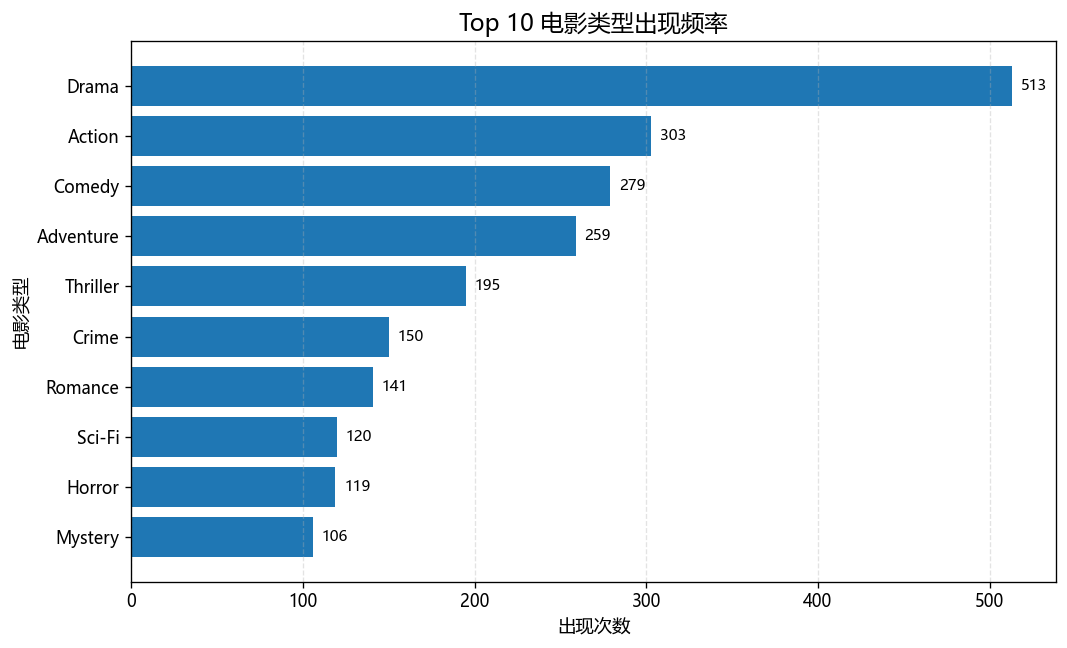

In [9]:

# 拆分多类型字段，统计单个类型频次
genre_exploded = df[["title", "genre_list"]].explode("genre_list").rename(columns={"genre_list": "genre_single"})
genre_exploded["genre_single"] = genre_exploded["genre_single"].str.strip()

top_genres = genre_exploded["genre_single"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(top_genres.index, top_genres.values)
ax.set_title("Top 10 电影类型出现频率")
ax.set_xlabel("出现次数")
ax.set_ylabel("电影类型")
ax.grid(axis="x", linestyle="--", alpha=0.35)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 5, bar.get_y() + bar.get_height()/2, f"{int(width)}", va="center", fontsize=9)

plt.tight_layout()
plt.show()



**图 1 解读：**  
样本中 Drama、Action、Comedy、Adventure 等类型出现频率较高，说明该数据集以剧情、动作、喜剧和冒险类电影为主。由于电影类型允许多选，所以类型频次之和会大于电影总数。



### 图 2：电影评分分布

这个图回答“电影评分整体集中在什么水平，以及是否存在明显高分或低分电影”。


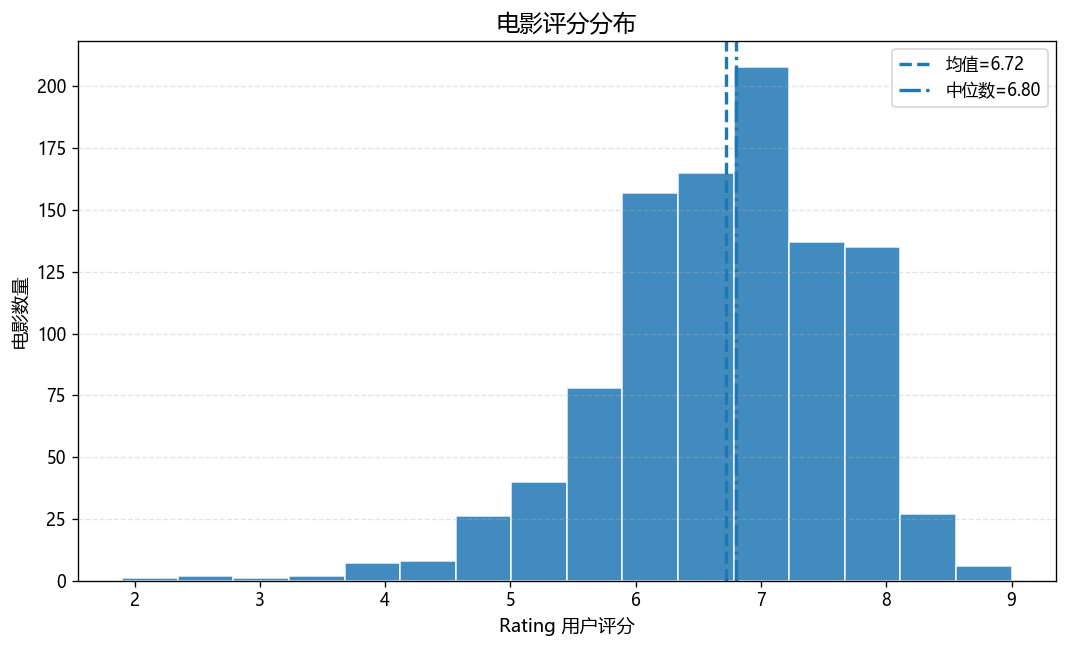

In [10]:

rating_mean = df["rating"].mean()
rating_median = df["rating"].median()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(df["rating"].dropna(), bins=16, edgecolor="white", alpha=0.85)
ax.axvline(rating_mean, linestyle="--", linewidth=2, label=f"均值={rating_mean:.2f}")
ax.axvline(rating_median, linestyle="-.", linewidth=2, label=f"中位数={rating_median:.2f}")
ax.set_title("电影评分分布")
ax.set_xlabel("Rating 用户评分")
ax.set_ylabel("电影数量")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend()

plt.tight_layout()
plt.show()



**图 2 解读：**  
电影评分主要集中在 6—8 分之间，均值约为 6.72，中位数约为 6.80，说明样本电影整体口碑处于中等偏上水平。低于 5 分和高于 8.5 分的电影数量相对较少。



### 图 3：主要电影类型的平均评分比较

这里使用电影的 `main_genre` 进行分组，并且只保留样本量不少于 20 的类型，避免小样本类型造成误判。


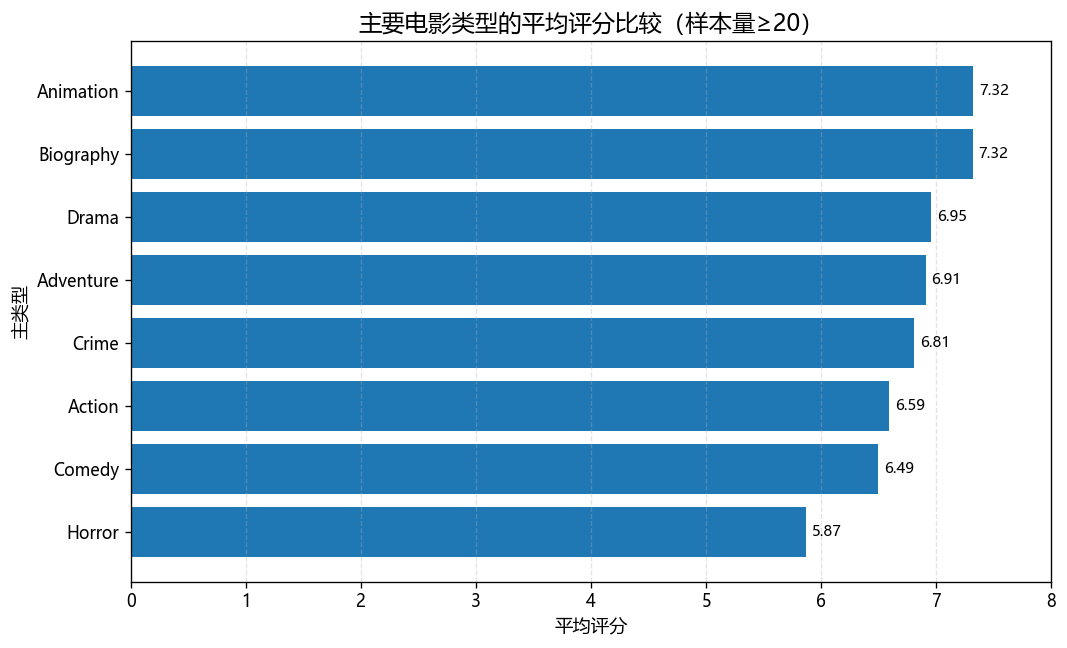

,movie_count,avg_rating
main_genre,,
Animation,49,7.32
Biography,64,7.32
Drama,195,6.95
Adventure,75,6.91
Crime,71,6.81
Action,293,6.59
Comedy,175,6.49
Horror,46,5.87


In [11]:

genre_rating = (
    df.groupby("main_genre")
    .agg(movie_count=("title", "count"), avg_rating=("rating", "mean"))
    .query("movie_count >= 20")
    .sort_values("avg_rating")
)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(genre_rating.index, genre_rating["avg_rating"])
ax.set_title("主要电影类型的平均评分比较（样本量≥20）")
ax.set_xlabel("平均评分")
ax.set_ylabel("主类型")
ax.set_xlim(0, 8)
ax.grid(axis="x", linestyle="--", alpha=0.35)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.05, bar.get_y() + bar.get_height()/2, f"{width:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

display(genre_rating.sort_values("avg_rating", ascending=False).round(2))



**图 3 解读：**  
在样本量较充足的主类型中，Animation、Biography、Drama 的平均评分相对较高；Horror 的平均评分偏低。说明不同类型电影在用户口碑上存在一定差异，偏剧情、人物传记或动画类电影更容易获得较高评分。



### 图 4：主要电影类型的票房中位数比较

票房数据存在少数超级大片，平均数容易被极端值拉高，因此这里采用中位数作为更稳健的比较指标。


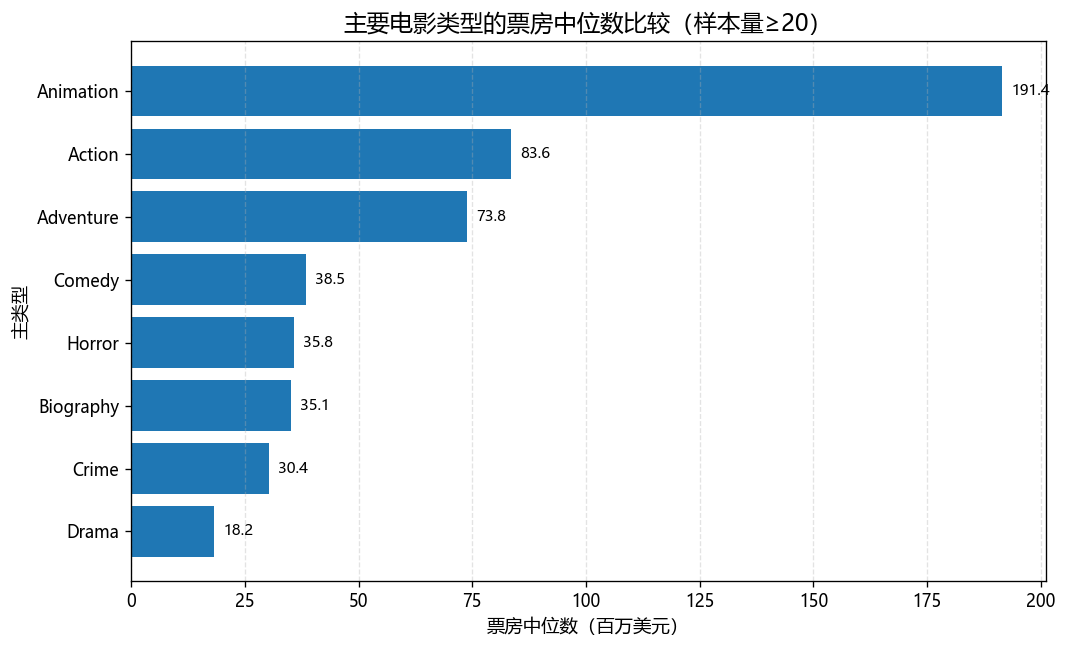

,movie_count,median_revenue
main_genre,,
Animation,49,191.45
Action,293,83.57
Adventure,75,73.82
Comedy,175,38.52
Horror,46,35.79
Biography,64,35.12
Crime,71,30.38
Drama,195,18.22


In [12]:

genre_revenue = (
    df.groupby("main_genre")
    .agg(movie_count=("title", "count"), median_revenue=("revenue_millions", "median"))
    .query("movie_count >= 20")
    .dropna()
    .sort_values("median_revenue")
)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(genre_revenue.index, genre_revenue["median_revenue"])
ax.set_title("主要电影类型的票房中位数比较（样本量≥20）")
ax.set_xlabel("票房中位数（百万美元）")
ax.set_ylabel("主类型")
ax.grid(axis="x", linestyle="--", alpha=0.35)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height()/2, f"{width:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

display(genre_revenue.sort_values("median_revenue", ascending=False).round(2))



**图 4 解读：**  
Animation 的票房中位数明显较高，Adventure 和 Action 的商业表现也较突出；Drama 虽然评分较高，但票房中位数相对较低。这说明“口碑表现”和“商业收入”并不完全一致，不同类型电影的市场属性存在差异。



### 图 5：投票数与票房收入的关系

这个图回答“受关注程度更高的电影，是否更容易获得更高票房”。投票数差异非常大，因此横轴使用对数坐标，使图形更易读。


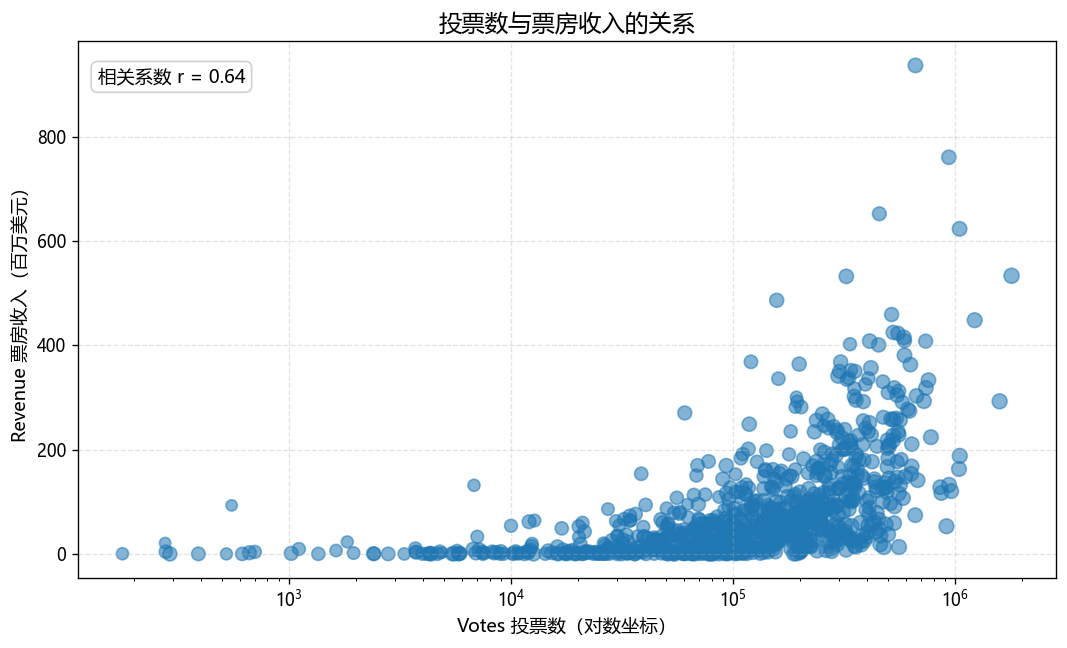

In [13]:

scatter_data = df.dropna(subset=["votes", "revenue_millions", "rating"]).copy()
corr_votes_revenue = scatter_data[["votes", "revenue_millions"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(9, 5.5))
points = ax.scatter(
    scatter_data["votes"], 
    scatter_data["revenue_millions"],
    s=18 + scatter_data["rating"] * 7,
    alpha=0.55
)
ax.set_xscale("log")
ax.set_title("投票数与票房收入的关系")
ax.set_xlabel("Votes 投票数（对数坐标）")
ax.set_ylabel("Revenue 票房收入（百万美元）")
ax.grid(True, linestyle="--", alpha=0.35)
ax.text(
    0.02, 0.95, 
    f"相关系数 r = {corr_votes_revenue:.2f}",
    transform=ax.transAxes,
    fontsize=11,
    va="top",
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.8", alpha=0.9)
)

plt.tight_layout()
plt.show()



**图 5 解读：**  
投票数和票房收入呈较明显正相关，相关系数约为 0.64。说明被更多观众关注和评价的电影，往往也有更高的商业收入。但散点并非完全落在一条直线上，说明票房还受题材、档期、发行规模、IP 影响力等因素影响。



### 图 6：上映年份与电影数量、平均评分变化

这个图回答“不同年份样本电影数量和平均评分是否存在变化趋势”。


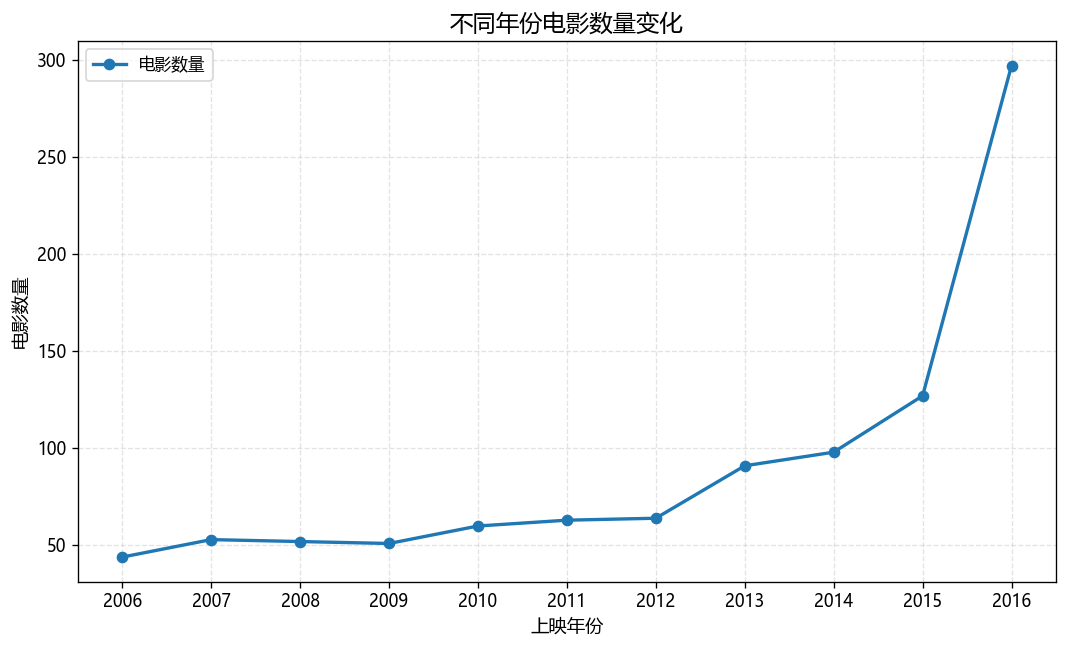

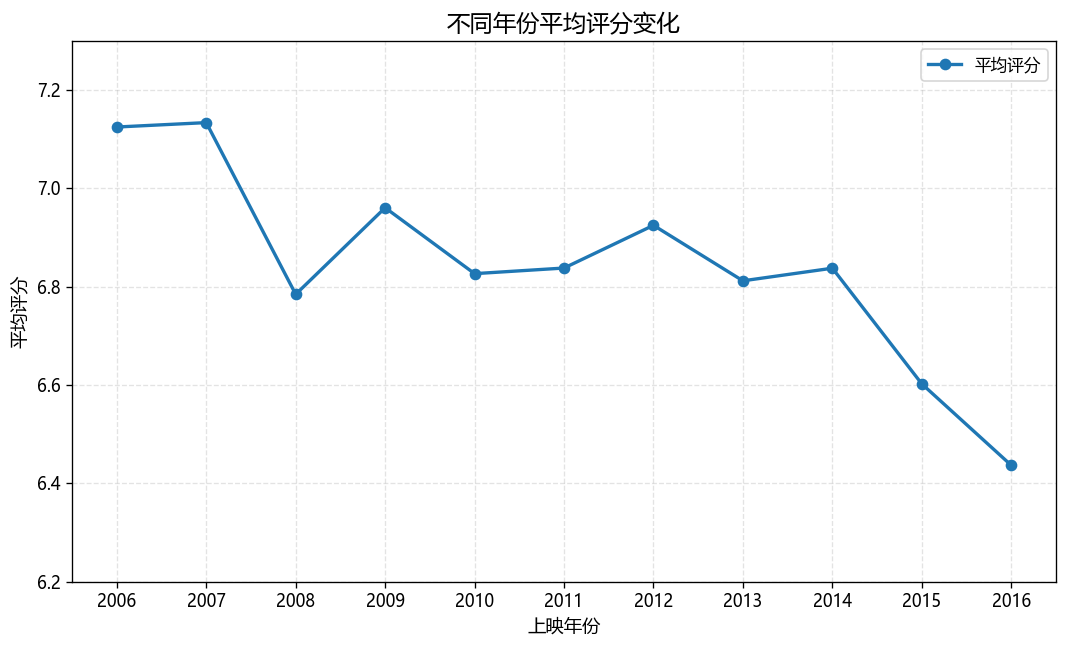

,year,movie_count,avg_rating,total_revenue
0,2006,44,7.12,"3,624.46"
1,2007,53,7.13,"4,306.23"
2,2008,52,6.78,"5,053.22"
3,2009,51,6.96,"5,292.26"
4,2010,60,6.83,"5,989.65"
5,2011,63,6.84,"5,431.96"
6,2012,64,6.92,"6,910.29"
7,2013,91,6.81,"7,666.72"
8,2014,98,6.84,"7,997.40"
9,2015,127,6.60,"8,854.12"


In [14]:

year_summary = (
    df.groupby("year")
    .agg(movie_count=("title", "count"), avg_rating=("rating", "mean"), total_revenue=("revenue_millions", "sum"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(year_summary["year"], year_summary["movie_count"], marker="o", linewidth=2, label="电影数量")
ax.set_title("不同年份电影数量变化")
ax.set_xlabel("上映年份")
ax.set_ylabel("电影数量")
ax.set_xticks(year_summary["year"])
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(year_summary["year"], year_summary["avg_rating"], marker="o", linewidth=2, label="平均评分")
ax.set_title("不同年份平均评分变化")
ax.set_xlabel("上映年份")
ax.set_ylabel("平均评分")
ax.set_xticks(year_summary["year"])
ax.set_ylim(6.2, 7.3)
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend()

plt.tight_layout()
plt.show()

display(year_summary.round(2))



**图 6 解读：**  
样本中 2016 年电影数量最多，这可能与数据收集范围或排名机制有关。平均评分从 2006—2007 年的较高水平逐渐波动下降，2016 年平均评分相对较低。需要注意，2016 年样本数量明显更多，因此年度比较可能受到样本结构影响。



### 图 7：Rating、Metascore、Votes、Revenue 的相关性

相关性热力图用于观察多个数值变量之间的整体关系。


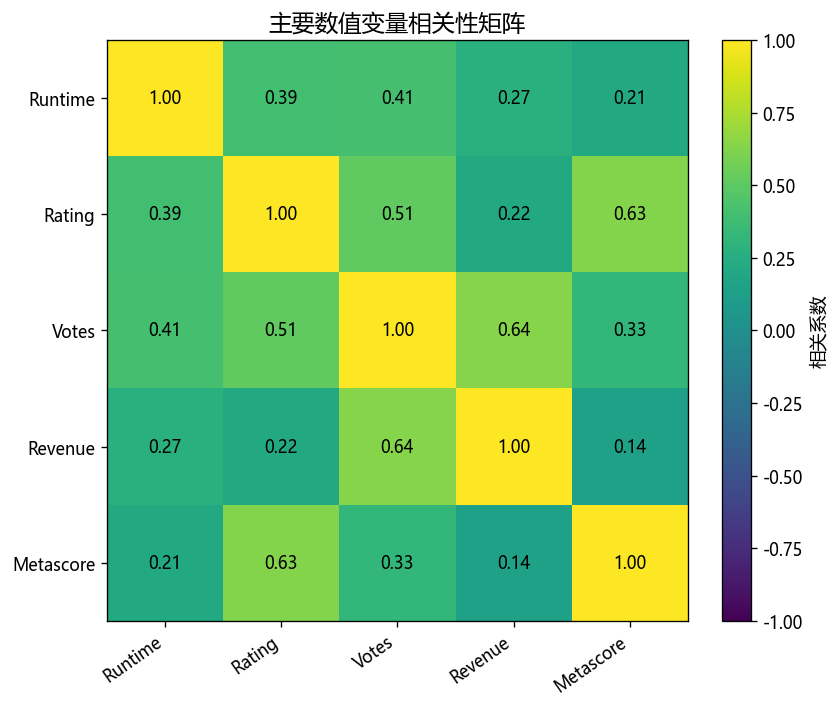

,runtime_minutes,rating,votes,revenue_millions,metascore
runtime_minutes,1.00,0.39,0.41,0.27,0.21
rating,0.39,1.00,0.51,0.22,0.63
votes,0.41,0.51,1.00,0.64,0.33
revenue_millions,0.27,0.22,0.64,1.00,0.14
metascore,0.21,0.63,0.33,0.14,1.00


In [15]:

corr_cols = ["runtime_minutes", "rating", "votes", "revenue_millions", "metascore"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, vmin=-1, vmax=1)
ax.set_title("主要数值变量相关性矩阵")
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(["Runtime", "Rating", "Votes", "Revenue", "Metascore"], rotation=35, ha="right")
ax.set_yticklabels(["Runtime", "Rating", "Votes", "Revenue", "Metascore"])

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("相关系数")
plt.tight_layout()
plt.show()

display(corr.round(3))



**图 7 解读：**  
用户评分 Rating 与媒体评分 Metascore 的相关性较高，说明观众评价与专业评价在总体方向上较一致。Votes 与 Revenue 的相关性也较高，说明关注度与商业表现关系密切。Rating 与 Revenue 的相关性较弱，说明高评分并不一定直接转化为高票房。



### 图 8：不同评分等级的票房表现

这个图进一步比较评分等级与票房之间的关系，检验“高评分电影是否一定高票房”。


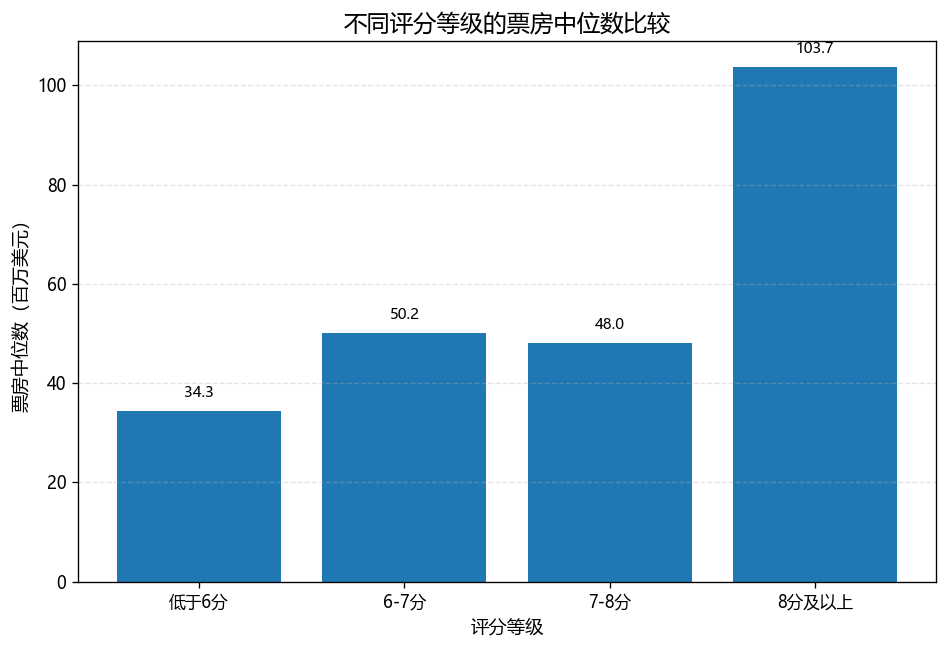

,rating_level,movie_count,median_revenue,avg_revenue
0,低于6分,133,34.33,52.70
1,6-7分,322,50.16,69.36
2,7-8分,343,48.04,94.36
3,8分及以上,74,103.72,143.60


In [16]:

rating_revenue = (
    df.dropna(subset=["rating_level", "revenue_millions"])
    .groupby("rating_level")
    .agg(movie_count=("title", "count"), median_revenue=("revenue_millions", "median"), avg_revenue=("revenue_millions", "mean"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(rating_revenue["rating_level"].astype(str), rating_revenue["median_revenue"])
ax.set_title("不同评分等级的票房中位数比较")
ax.set_xlabel("评分等级")
ax.set_ylabel("票房中位数（百万美元）")
ax.grid(axis="y", linestyle="--", alpha=0.35)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 2, f"{height:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

display(rating_revenue.round(2))



**图 8 解读：**  
不同评分等级的票房中位数并不是简单单调上升。评分较高通常代表口碑更好，但票房还受到类型、宣传、发行规模、明星阵容和 IP 基础等因素影响。因此，在电影数据中应区分“口碑指标”和“商业指标”。



## 8. 重点电影与导演/演员补充分析

为了增加分析深度，这里展示票房最高电影和评分最高电影，帮助理解极端值并不是错误数据，而是热门影片带来的真实差异。


In [17]:

top_revenue = (
    df.dropna(subset=["revenue_millions"])
    .sort_values("revenue_millions", ascending=False)
    [["title", "year", "main_genre", "director", "rating", "votes", "revenue_millions"]]
    .head(10)
)

top_rating = (
    df.sort_values(["rating", "votes"], ascending=[False, False])
    [["title", "year", "main_genre", "director", "rating", "votes", "revenue_millions", "metascore"]]
    .head(10)
)

print("票房最高的前 10 部电影：")
display(top_revenue)

print("评分最高且投票数较高的前 10 部电影：")
display(top_rating)


票房最高的前 10 部电影：


,title,year,main_genre,director,rating,votes,revenue_millions
50,Star Wars: Episode VII - The Force Awakens,2015,Action,J.J. Abrams,8.10,661608,936.63
87,Avatar,2009,Action,James Cameron,7.80,935408,760.51
85,Jurassic World,2015,Action,Colin Trevorrow,7.00,455169,652.18
76,The Avengers,2012,Action,Joss Whedon,8.10,1045588,623.28
54,The Dark Knight,2008,Action,Christopher Nolan,9.00,1791916,533.32
12,Rogue One,2016,Action,Gareth Edwards,7.90,323118,532.17
119,Finding Dory,2016,Animation,Andrew Stanton,7.40,157026,486.29
94,Avengers: Age of Ultron,2015,Action,Joss Whedon,7.40,516895,458.99
124,The Dark Knight Rises,2012,Action,Christopher Nolan,8.50,1222645,448.13
578,The Hunger Games: Catching Fire,2013,Action,Francis Lawrence,7.60,525646,424.65


评分最高且投票数较高的前 10 部电影：


,title,year,main_genre,director,rating,votes,revenue_millions,metascore
54,The Dark Knight,2008,Action,Christopher Nolan,9.00,1791916,533.32,82.00
80,Inception,2010,Action,Christopher Nolan,8.80,1583625,292.57,74.00
117,Dangal,2016,Action,Nitesh Tiwari,8.80,48969,11.15,NaN
36,Interstellar,2014,Adventure,Christopher Nolan,8.60,1047747,187.99,74.00
249,The Intouchables,2011,Biography,Olivier Nakache,8.60,557965,13.18,57.00
96,Kimi no na wa,2016,Animation,Makoto Shinkai,8.60,34110,4.68,79.00
124,The Dark Knight Rises,2012,Action,Christopher Nolan,8.50,1222645,448.13,78.00
99,The Departed,2006,Crime,Martin Scorsese,8.50,937414,132.37,85.00
64,The Prestige,2006,Drama,Christopher Nolan,8.50,913152,53.08,66.00
133,Whiplash,2014,Drama,Damien Chazelle,8.50,477276,13.09,88.00


In [18]:

# 导演维度：至少有 3 部作品的导演，比较平均评分
director_summary = (
    df.groupby("director")
    .agg(movie_count=("title", "count"), avg_rating=("rating", "mean"), total_revenue=("revenue_millions", "sum"))
    .query("movie_count >= 3")
    .sort_values("avg_rating", ascending=False)
    .head(10)
)

display(director_summary.round(2))


,movie_count,avg_rating,total_revenue
director,,,
Christopher Nolan,5,8.68,"1,515.09"
Martin Scorsese,5,7.92,458.11
Quentin Tarantino,4,7.90,337.44
Wes Anderson,3,7.90,125.58
David Fincher,5,7.82,527.72
Alejandro González Iñárritu,3,7.77,260.28
Denis Villeneuve,5,7.76,216.21
Matthew Vaughn,4,7.72,361.05
Clint Eastwood,4,7.70,658.99



**补充分析解读：**  
票房最高电影多集中在动作、冒险、科幻、动画等商业类型中，这些类型通常具备更强的视觉效果和大众市场属性。评分最高电影并不都对应最高票房，说明口碑评价与市场收入虽然有关联，但并不是同一个维度。



## 9. 综合结论

根据以上数据清洗、统计分析和可视化结果，可以得到以下结论：

1. **数据整体质量较好，但票房和媒体评分存在缺失。**  
   数据共有 1000 条记录，完全重复行数量为 0。缺失值主要集中在 `Revenue (Millions)` 和 `Metascore` 两个字段，因此在涉及票房或媒体评分的分析中，应使用非缺失样本，而不应简单把缺失值填为 0。

2. **样本电影类型以剧情、动作、喜剧和冒险为主。**  
   拆分多类型字段后，Drama、Action、Comedy、Adventure 出现频率较高，说明该数据集覆盖了主流商业片和剧情片类型。电影类型结构会影响后续的评分和票房分析。

3. **电影评分整体集中在中等偏上水平。**  
   用户评分均值约为 6.72，中位数约为 6.80，多数电影集中在 6—8 分区间，说明样本整体口碑较稳定，但真正高分电影数量相对有限。

4. **不同类型电影在口碑和票房上表现不同。**  
   Animation、Biography、Drama 等类型平均评分较高；Animation、Adventure、Action 等类型票房中位数较高。Drama 评分较高但票房中位数并不突出，说明“口碑好”和“票房高”并不完全等价。

5. **投票数与票房收入关系较强，评分与票房关系较弱。**  
   Votes 与 Revenue 的相关系数约为 0.64，说明关注度越高的电影往往票房越高；Rating 与 Revenue 的相关性相对较弱，说明高评分电影未必一定高票房。商业表现不仅取决于口碑，也受到题材、发行、宣传、IP 和明星阵容等因素影响。

6. **观众评分和媒体评分具有较高一致性。**  
   Rating 与 Metascore 的相关性较高，说明观众评价和专业评价在整体方向上较一致。但二者并不完全相同，仍可能因评价标准不同产生差异。

总体来看，本数据集适合用于电影市场表现与口碑评价的探索性分析。较合理的分析方式是同时关注类型、年份、评分、投票数和票房，而不是只依据单一指标评价电影表现。
